# Inception · Бустинги + доменные признаки

Третий ноутбук — выжимаем максимум. Опирается на выводы `02_model.ipynb`:
импутация `eog_burst_index` через `IterativeImputer` (внутри пайплайна, без утечки).

**Что нового:**
1. **Доменные признаки** на основе физиологии сна (подсказка экспертов по ЭЭГ).
2. **Градиентный бустинг**: LightGBM, XGBoost, CatBoost.
3. Финальный **ансамбль** (soft voting) лучших бустеров → `submission.csv`.

Метрика — accuracy, оценка через StratifiedKFold (5 фолдов).

## 1. Импорты и загрузка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier,
                              VotingClassifier)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")

train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()

train: (9000, 23)  test: (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## 2. Доменные признаки (физиология сна)

Подсказка экспертов: стадии сна различаются по спектральной мощности ЭЭГ.
Данные — z-score, поэтому комбинируем признаки **сложением/вычитанием**
(деление на z-score некорректно — значения бывают отрицательными).

| Признак | Формула | Физиология |
|---|---|---|
| `deep_idx` | delta + slow_osc | глубокий сон **N3** |
| `n2_idx` | sigma + spindle_density + kcomplex | стадия **N2** (веретёна, К-комплексы) |
| `wake_idx` | alpha + beta | бодрствование |
| `onset_idx` | theta − alpha | засыпание **N1** |
| `slow_fast` | (delta+theta) − (beta+gamma) | общая «замедленность» ЭЭГ |

In [2]:
# базовые 21 признак
base_features = [c for c in train.columns if c not in ("id", "sleep_stage")]

def add_domain(df):
    """Добавляет физиологически осмысленные составные признаки.
       Используются только EEG-признаки (без пропусков), eog_burst_index не трогаем."""
    X = df[base_features].copy()
    X["deep_idx"]  = X["eeg_delta_power"] + X["eeg_slow_osc_power"]                       # N3
    X["n2_idx"]    = X["eeg_sigma_power"] + X["eeg_spindle_density"] + X["eeg_kcomplex_rate"]  # N2
    X["wake_idx"]  = X["eeg_alpha_power"] + X["eeg_beta_power"]                           # бодрствование
    X["onset_idx"] = X["eeg_theta_power"] - X["eeg_alpha_power"]                          # засыпание N1
    X["slow_fast"] = (X["eeg_delta_power"] + X["eeg_theta_power"]) - (X["eeg_beta_power"] + X["eeg_gamma_power"])
    return X

X = add_domain(train)
y = train["sleep_stage"].copy()
X_test = add_domain(test)
print("Всего признаков:", X.shape[1], "(было", len(base_features), "+ 5 доменных)")
X.head()

Всего признаков: 26 (было 21 + 5 доменных)


,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,...,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,deep_idx,n2_idx,wake_idx,onset_idx,slow_fast
0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,...,-0.59521,1.71154,1.93342,1.57365,-1.36230,0.34215,-4.54816,14.06591,-8.92782,-4.83677
1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,...,2.16016,-4.32301,1.07270,-2.43903,-0.37271,-1.97953,-0.49879,-1.07771,-0.72788,3.41104
2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,...,-4.60411,0.37967,-2.06913,2.67324,NaN,0.23722,3.47434,-8.32131,5.74534,9.52378
3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,...,2.32790,0.78319,0.98233,1.53824,-0.25040,0.24704,-1.92771,1.52553,-1.75934,-3.52110
4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,...,0.22130,-1.44020,1.35760,-3.07701,-1.04947,-3.90736,5.31818,-9.96733,5.04059,6.68416


## 2b. Проверка: маркеры различают стадии?

Если экспертные маркеры верны, их средние значения должны заметно различаться
между стадиями сна.

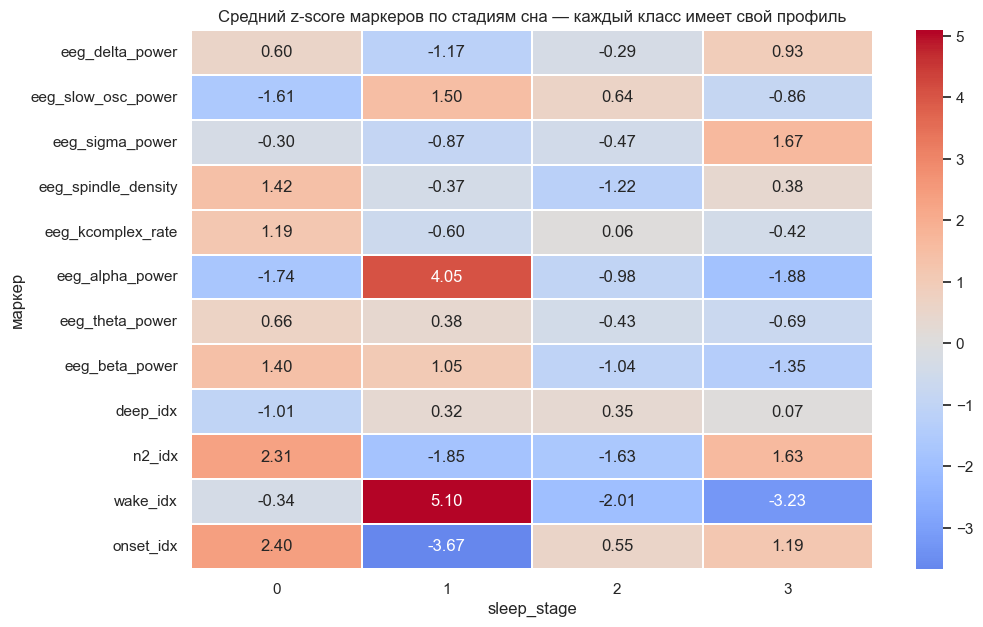

In [3]:
markers = ["eeg_delta_power","eeg_slow_osc_power","eeg_sigma_power","eeg_spindle_density",
           "eeg_kcomplex_rate","eeg_alpha_power","eeg_theta_power","eeg_beta_power",
           "deep_idx","n2_idx","wake_idx","onset_idx"]
means = X.assign(stage=y).groupby("stage")[markers].mean()

plt.figure(figsize=(11, 7))
sns.heatmap(means.T, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.3)
plt.title("Средний z-score маркеров по стадиям сна — каждый класс имеет свой профиль")
plt.xlabel("sleep_stage"); plt.ylabel("маркер")
plt.show()

## 3. Кросс-валидация: импутер внутри пайплайна

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipe(model):
    # импутер заполняет eog_burst_index, обучаясь только на train-фолде (без утечки)
    return Pipeline([("imputer", IterativeImputer(random_state=42, max_iter=10)),
                     ("model", model)])

def cv_accuracy(model):
    s = cross_val_score(make_pipe(model), X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return s.mean(), s.std()

results = {}

## 4. Бустинги по отдельности

In [5]:
lgb = LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbose=-1)
m, s = cv_accuracy(lgb); results["lightgbm"] = m
print(f"LightGBM:  {m:.4f} +/- {s:.4f}")

LightGBM:  0.8316 +/- 0.0090


In [6]:
xgb = XGBClassifier(n_estimators=800, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, verbosity=0, eval_metric="mlogloss")
m, s = cv_accuracy(xgb); results["xgboost"] = m
print(f"XGBoost:   {m:.4f} +/- {s:.4f}")

XGBoost:   0.8334 +/- 0.0087


In [7]:
cat = CatBoostClassifier(iterations=800, learning_rate=0.03, depth=6,
        l2_leaf_reg=3, random_state=42, verbose=0)
m, s = cv_accuracy(cat); results["catboost"] = m
print(f"CatBoost:  {m:.4f} +/- {s:.4f}")

CatBoost:  0.8371 +/- 0.0103


## 5. Ансамбль бустеров (soft voting)

In [8]:
# три РАЗНЫХ бустера голосуют вероятностями — устойчивее одиночной модели
ensemble = VotingClassifier(
    estimators=[("cat", cat), ("lgb", lgb), ("xgb", xgb)],
    voting="soft", n_jobs=-1,
)
m, s = cv_accuracy(ensemble); results["ensemble_boost"] = m
print(f"Ensemble (Cat+LGBM+XGB): {m:.4f} +/- {s:.4f}")

Ensemble (Cat+LGBM+XGB): 0.8369 +/- 0.0097


## 6. Сравнение

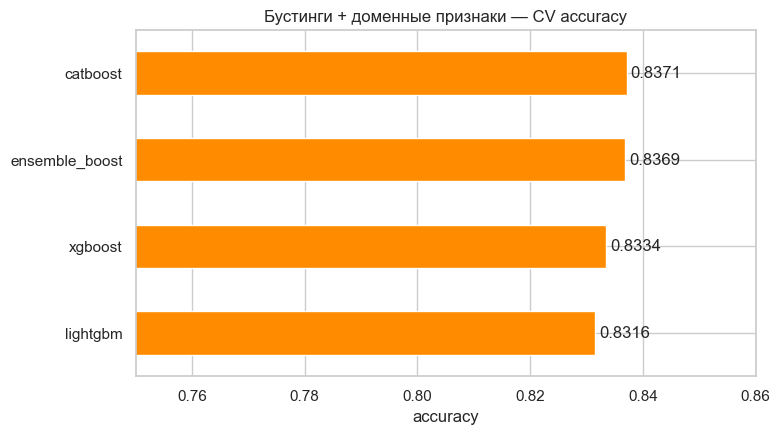

catboost          0.837111
ensemble_boost    0.836889
xgboost           0.833444
lightgbm          0.831556
dtype: float64

In [9]:
res = pd.Series(results).sort_values()
plt.figure(figsize=(8, 4.5))
res.plot(kind="barh", color="darkorange")
plt.title("Бустинги + доменные признаки — CV accuracy")
plt.xlabel("accuracy"); plt.xlim(0.75, 0.86)
for i, v in enumerate(res.values):
    plt.text(v + 0.0007, i, f"{v:.4f}", va="center")
plt.show()
res.sort_values(ascending=False)

## 7. Диагностика лучшей модели

Holdout accuracy: 0.8433

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       400
           1       0.85      0.86      0.85       489
           2       0.81      0.83      0.82       447
           3       0.84      0.83      0.84       464

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.84      0.84      0.84      1800



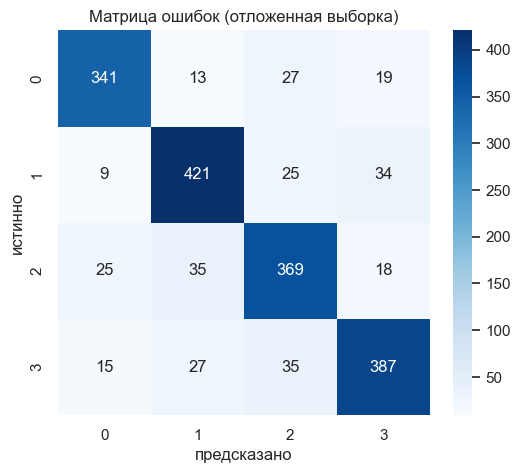

In [10]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
best = make_pipe(ensemble).fit(X_tr, y_tr)
pred_val = best.predict(X_val)
print(f"Holdout accuracy: {accuracy_score(y_val, pred_val):.4f}\n")
print(classification_report(y_val, pred_val))

cm = confusion_matrix(y_val, pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Матрица ошибок (отложенная выборка)")
plt.xlabel("предсказано"); plt.ylabel("истинно")
plt.show()

## 8. Финальное обучение и submission

In [11]:
# обучаем ансамбль на ВСЁМ train и предсказываем test
final_model = make_pipe(VotingClassifier(
    estimators=[
        ("cat", CatBoostClassifier(iterations=800, learning_rate=0.03, depth=6, l2_leaf_reg=3, random_state=42, verbose=0)),
        ("lgb", LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbose=-1)),
        ("xgb", XGBClassifier(n_estimators=800, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbosity=0, eval_metric="mlogloss")),
    ],
    voting="soft", n_jobs=-1,
)).fit(X, y)

test_pred = final_model.predict(X_test)
print("Предсказано меток:", len(test_pred))

Предсказано меток: 5000


In [12]:
submission = pd.DataFrame({"id": test["id"], "sleep_stage": test_pred})
assert list(submission.columns) == ["id", "sleep_stage"]
assert len(submission) == 5000
assert submission["sleep_stage"].isin([0, 1, 2, 3]).all()

submission.to_csv("submission.csv", index=False)
print("Сохранено: submission.csv  (перезаписал версию из 02)")
print(submission["sleep_stage"].value_counts().sort_index())
submission.head()

Сохранено: submission.csv  (перезаписал версию из 02)
sleep_stage
0    1119
1    1288
2    1300
3    1293
Name: count, dtype: int64


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 9. Отправка на Kaggle

`submission.csv` готов — **заливаю на Kaggle вручную** через сайт.

**Что дало прирост (итог по всем ноутбукам):**
- 0.27 → 0.82: деревья/HGB вместо линейных моделей
- 0.82 → 0.834: умная импутация `eog_burst_index` (IterativeImputer)
- 0.834 → ~0.837: бустинги + доменные признаки по физиологии сна

**Куда расти дальше:** подбор гиперпараметров бустеров (Optuna),
out-of-fold стэкинг, добавление новых доменных взаимодействий.